# Fase 3 — Modelagem Supervisionada (grão MUNICÍPIO)

**Objetivo:** antecipar quais municípios **não vão atingir a meta de alfabetização** do ano.

É a pergunta de negócio mais acionável do desafio. No grão aluno o modelo estima risco; aqui ele
aponta **onde** agir — o município é a unidade que recebe recurso, formação de professor e programa
de reforço.

In [1]:
import sys
sys.path.append("..")

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

from src import config
from src.evaluation import metrics
from src.preprocessing import pipeline as pp
from src.visualization import plots

plots.aplicar_estilo()
resultado = json.loads((config.REPORTS_DIR / "metricas_municipio.json").read_text(encoding="utf-8"))
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)

## 1. Definição do alvo

O Compromisso Nacional define, para cada município, uma **trajetória de metas de 2024 a 2030**,
terminando em 80%. O alvo binário é direto:

$$\text{nao\_atingiu\_meta} = \mathbb{1}\left[\text{taxa observada}_t < \text{meta}_t\right]$$

O recorte é a **rede Municipal**, que é a rede à qual as metas se aplicam.

## 2. Uma armadilha estrutural: por que 2024 não serve como treino

O desenho natural seria treinar em 2024 e testar em 2025 (out-of-time), como no modelo de aluno.
Ao fazer isso, o resultado foi estranho: **AUC 0,65 no teste — abaixo de uma regra de uma linha**
("ordene os municípios pelo quanto falta para a meta", AUC 0,74).

A investigação explicou o porquê.

In [2]:
diag = pd.DataFrame(resultado["diagnostico_safras"]).T
diag.index.name = "safra"
diag.rename(columns={
    "corr_meta_com_taxa_anterior": "corr(meta do ano, taxa do ano anterior)",
    "dp_esforco_necessario": "desvio-padrão do esforço necessário (p.p.)",
    "auc_do_esforco_necessario": "AUC do esforço necessário isolado",
}).round(3)

,"corr(meta do ano, taxa do ano anterior)",desvio-padrão do esforço necessário (p.p.),AUC do esforço necessário isolado
safra,,,
2024,0.977,5.999,0.505
2025,0.641,14.755,0.744


As metas municipais foram **calculadas a partir da linha de base de 2023**. Para o ano de 2024, a
meta e a taxa do ano anterior saem praticamente da mesma medição (correlação de 0,98) — e o
"esforço necessário" vira quase uma constante, com AUC de 0,505: **nenhum poder discriminante**.

Em 2025 a defasagem é real (meta ancorada em 2023, contexto vindo de 2024) e a mesma variável passa
a discriminar de verdade.

**Decisão:** a modelagem usa a safra de **2025**. O ano de 2024 fica como diagnóstico, documentando
por que foi descartado.

### Como validar com uma única safra utilizável

- **StratifiedKFold** — generalizar para municípios novos dentro de estados já observados. É o
  cenário real de uso: todos os municípios da projeção estão em UFs presentes na base.
- **GroupKFold por UF** — generalizar para **estados inteiros** nunca vistos. Teste de estresse,
  para delimitar até onde o modelo pode ser estendido.

In [3]:
base = pd.read_csv(config.PROCESSED_DIR / f"municipio_{resultado['ano_base']}.csv")
X, y = pp.preparar_municipio(base)
print(f"Base {resultado['ano_base']}: {len(X):,} municípios | abaixo da meta: {y.mean():.1%}".replace(",", "."))
print(f"Atributos: {X.shape[1]}")
base[["taxa_observada", "mun_taxa_alfabetizacao_lag", "meta_ano",
      "esforco_necessario", "nao_atingiu_meta"]].describe().round(2)

Base 2025: 5.338 municípios | abaixo da meta: 27.6%
Atributos: 21


,taxa_observada,mun_taxa_alfabetizacao_lag,meta_ano,esforco_necessario,nao_atingiu_meta
count,5338.00,5338.00,5338.00,5338.00,5338.00
mean,72.36,63.17,65.24,2.07,0.28
std,16.03,19.22,12.63,14.76,0.45
min,0.00,4.00,14.05,-76.28,0.00
25%,61.19,48.92,57.16,-7.72,0.00
50%,73.75,64.35,66.93,2.14,0.00
75%,84.72,77.78,76.51,11.26,1.00
max,100.00,100.00,80.00,68.89,1.00


## 3. O baseline que o modelo precisa superar

Antes de qualquer modelo: ordenar os municípios pelo **esforço necessário** (meta do ano − taxa do
ano anterior) é uma conta de subtração. Se o modelo não superar isso, ele não se justifica.

In [4]:
print(f"Baseline analítico — AUC agregado:          {resultado['baseline_analitico_auc']:.4f}")
print(f"Baseline analítico — por fold estratificado: {resultado['baseline_analitico_auc_estratificado']:.4f}")
print(f"Baseline analítico — por fold de UF:         {resultado['baseline_analitico_auc_por_uf']:.4f}")

Baseline analítico — AUC agregado:          0.7442
Baseline analítico — por fold estratificado: 0.7443
Baseline analítico — por fold de UF:         0.7406


## 4. Comparação de modelos

In [5]:
pd.read_csv(config.REPORTS_DIR / "comparacao_modelos_municipio.csv").round(4)

,modelo,auc_estratificado,desvio_estratificado,auc_por_uf,desvio_por_uf
0,Random Forest,0.8017,0.0149,0.7449,0.0687
1,Regressão Logística,0.7925,0.0157,0.7427,0.0797
2,Baseline analítico (esforço necessário),0.7443,0.0000,0.7406,0.0000
3,LightGBM,0.8033,0.0149,0.7340,0.0723
4,Árvore de Decisão,0.7568,0.0153,0.7135,0.0649
5,Baseline (classe majoritária),0.5000,0.0000,0.5000,0.0000


Neste grão os modelos de árvore abrem vantagem clara sobre a regressão logística na validação
estratificada — há interação real entre "quanto falta para a meta" e "de que patamar o município
parte". Na validação por UF a vantagem desaparece: sinal de que parte do que o modelo aprende é o
**nível de cada estado**, não uma regra transferível.

## 5. Resultado fora da amostra

In [6]:
metrics.tabela_metricas({
    "In-sample": resultado["treino_in_sample"],
    "Fora da amostra (municípios novos)": resultado["fora_da_amostra"],
    "Fora da amostra, limiar calibrado": resultado["fora_da_amostra_limiar_otimizado"],
    "Teste de estresse (estados novos)": resultado["fora_da_amostra_por_uf"],
})

,roc_auc,pr_auc,acuracia,acuracia_balanceada,precisao,recall,f1,brier
In-sample,0.8732,0.7649,0.8320,0.7342,0.8051,0.5160,0.6289,0.1231
Fora da amostra (municípios novos),0.8058,0.6523,0.7921,0.6833,0.6941,0.4406,0.5390,0.1474
"Fora da amostra, limiar calibrado",0.8058,0.6523,0.7347,0.7307,0.5138,0.7217,0.6002,0.1474
Teste de estresse (estados novos),0.7204,0.4759,0.7197,0.6208,0.4904,0.3999,0.4405,0.1837


In [7]:
ganho_mun = resultado["fora_da_amostra"]["roc_auc"] - resultado["baseline_analitico_auc_estratificado"]
ganho_uf = resultado["fora_da_amostra_por_uf"]["roc_auc"] - resultado["baseline_analitico_auc_por_uf"]
print(f"Ganho sobre o baseline analítico — municípios novos: {ganho_mun:+.4f} AUC")
print(f"Ganho sobre o baseline analítico — estados novos:    {ganho_uf:+.4f} AUC")

Ganho sobre o baseline analítico — municípios novos: +0.0615 AUC
Ganho sobre o baseline analítico — estados novos:    -0.0202 AUC


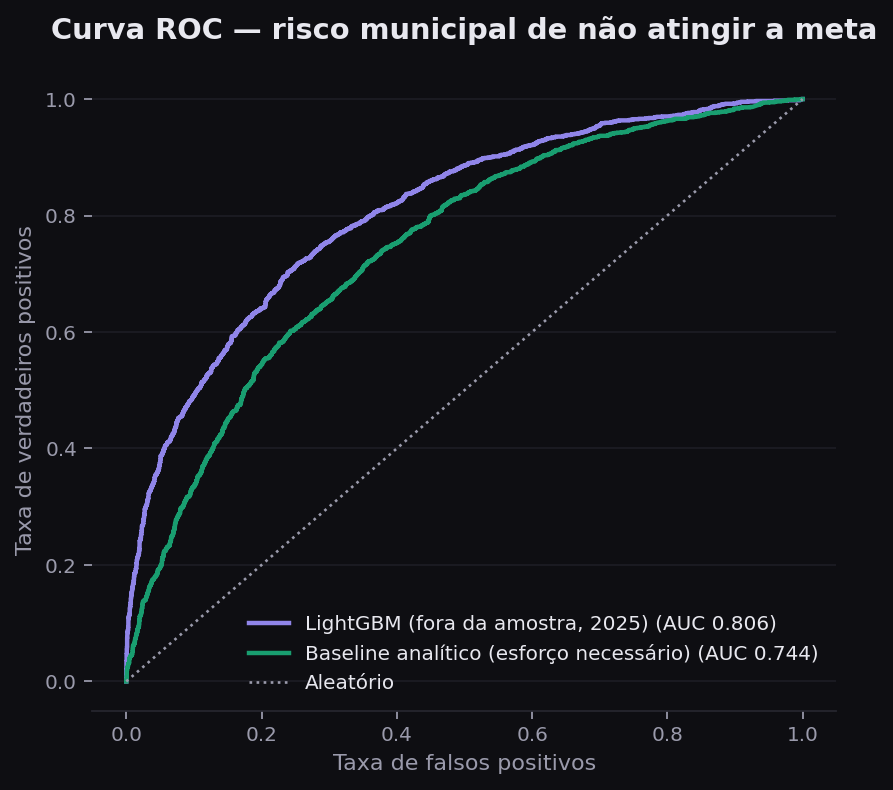

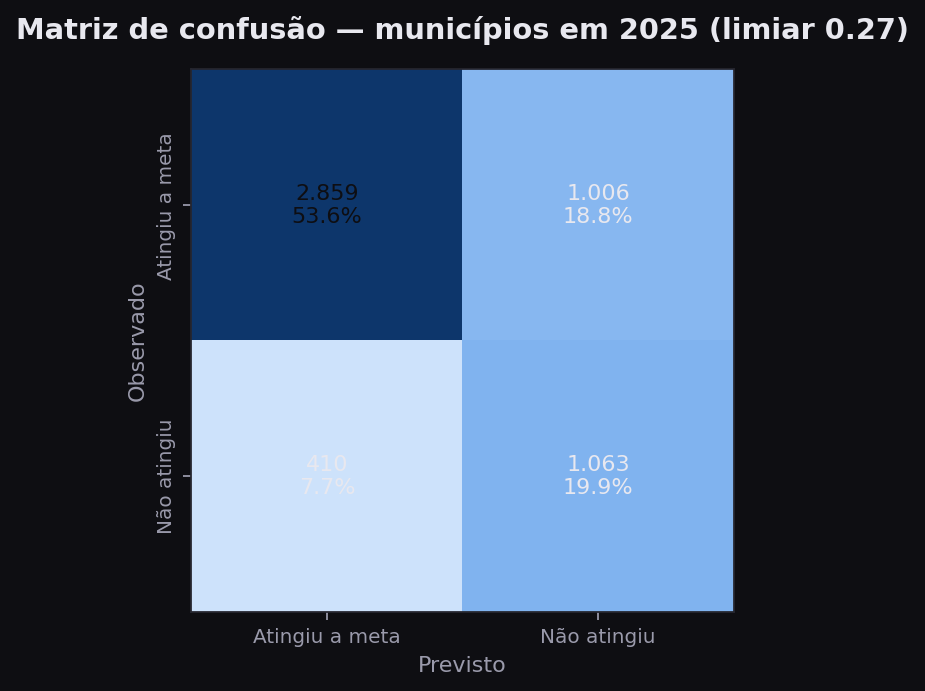

In [8]:
display(Image(filename="../images/10_roc_municipio.png"))
display(Image(filename="../images/11_matriz_confusao_municipio.png"))

### Leitura honesta

**Para municípios novos em estados conhecidos, o modelo entrega ganho real:** AUC 0,806 contra 0,744
do baseline. E o desempenho é substancialmente melhor que no grão aluno — no agregado, o ruído
individual se cancela. A média de mil crianças é muito mais previsível do que qualquer uma delas
isoladamente. É a evidência quantitativa da tese central do projeto: **inteligência territorial, não
rotulagem individual.**

**Para estados inteiros nunca vistos, o modelo perde para a conta de subtração.** O ganho é
intra-estadual: cada UF tem sua própria política e seu próprio patamar, e é isso que o modelo
aprende. Para um estado fora da base, não há o que transferir além da distância para a meta.

Como os 5.338 municípios da projeção estão todos em UFs observadas, a validação estratificada é a
que corresponde ao uso real — e o teste por UF define o limite de extrapolação.

### Limiar de decisão

O custo é assimétrico: não sinalizar um município que vai falhar significa não enviar apoio. O
limiar calibrado por acurácia balanceada eleva bastante o recall.

In [9]:
r0, r1 = resultado["fora_da_amostra"], resultado["fora_da_amostra_limiar_otimizado"]
print(f"Limiar 0,50  -> recall {r0['recall']:.3f} | precisão {r0['precisao']:.3f} | acurácia balanceada {r0['acuracia_balanceada']:.3f}")
print(f"Limiar {resultado['limiar_balanceado']:.2f}  -> recall {r1['recall']:.3f} | precisão {r1['precisao']:.3f} | acurácia balanceada {r1['acuracia_balanceada']:.3f}")

Limiar 0,50  -> recall 0.441 | precisão 0.694 | acurácia balanceada 0.683
Limiar 0.27  -> recall 0.722 | precisão 0.514 | acurácia balanceada 0.731


## 6. Aplicação: projeção de risco para 2026

O modelo é aplicado ao contexto **observado em 2025** contra a **meta de 2026** — uma predição de
verdade, sobre um resultado que ainda não aconteceu.

In [10]:
ranking = pd.read_csv(config.REPORTS_DIR / "ranking_risco_municipios_2026.csv")
p = resultado["projecao_2026"]
print(f"Municípios avaliados:                  {p['municipios_avaliados']:,}".replace(",", "."))
print(f"Em alto risco (acima do limiar):       {p['municipios_em_alto_risco']:,} ({p['pct_em_alto_risco']:.1f}%)".replace(",", "."))
print(f"Crianças avaliadas nesses municípios:  {p['criancas_em_municipios_de_alto_risco']:,}".replace(",", "."))
print(f"Esforço médio desse grupo:             {p['esforco_medio_alto_risco_pp']:.1f} p.p.")

Municípios avaliados:                  5.338
Em alto risco (acima do limiar):       1.691 (31.7%)
Crianças avaliadas nesses municípios:  857.718
Esforço médio desse grupo:             9.7 p.p.


In [11]:
ranking.head(20)[["municipio", "sigla_uf", "regiao", "taxa_2025", "meta_2026",
                  "esforco_necessario", "risco_nao_atingir_meta"]].round(3)

,municipio,sigla_uf,regiao,taxa_2025,meta_2026,esforco_necessario,risco_nao_atingir_meta
0,Canoas,RS,Sul,42.438,66.07,23.632,0.935
1,São Gabriel,RS,Sul,45.251,70.12,24.869,0.935
2,Passo Fundo,RS,Sul,40.376,68.81,28.434,0.934
3,Rio Grande,RS,Sul,36.819,66.59,29.771,0.933
4,Guaíba,RS,Sul,41.106,64.28,23.174,0.933
5,São Leopoldo,RS,Sul,41.001,68.04,27.039,0.932
6,Cachoeirinha,RS,Sul,46.895,68.56,21.665,0.932
7,Tramandaí,RS,Sul,43.613,66.70,23.087,0.929
8,Gravataí,RS,Sul,46.198,71.38,25.182,0.928
9,Pelotas,RS,Sul,30.139,54.37,24.231,0.927


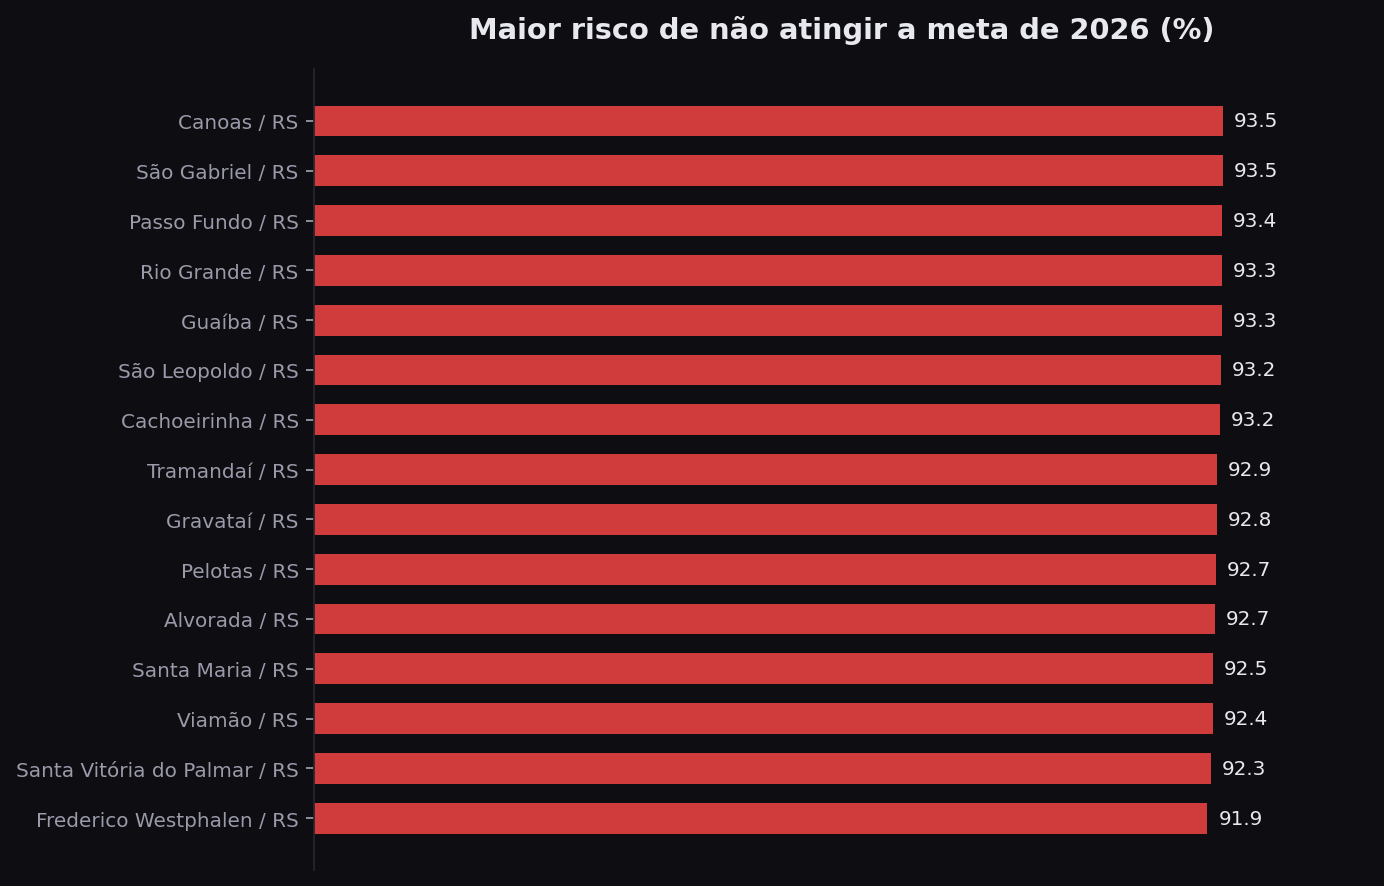

In [12]:
display(Image(filename="../images/12_top_municipios_risco.png"))

### Como um gestor usaria isso

`reports/ranking_risco_municipios_2026.csv` é o entregável operacional: lista priorizada, com
probabilidade de risco, taxa atual, meta e **quantos pontos percentuais faltam** — filtrável por UF,
região ou porte para montar a fila de atendimento.

In [13]:
por_uf = (ranking.groupby("sigla_uf")
          .agg(municipios=("id_municipio", "size"),
               risco_medio=("risco_nao_atingir_meta", "mean"),
               esforco_medio=("esforco_necessario", "mean"))
          .sort_values("risco_medio", ascending=False))
por_uf.round(3).head(12)

,municipios,risco_medio,esforco_medio
sigla_uf,,,
RS,432,0.460,9.920
RJ,92,0.429,2.715
SP,625,0.368,1.807
AM,55,0.350,4.935
SC,253,0.314,-1.136
PA,142,0.303,1.650
MA,217,0.257,-3.882
RN,151,0.246,2.117
PE,184,0.246,-2.983


## 7. Limitações deste modelo

- **Uma safra utilizável.** Só 2025 permite a modelagem; 2024 é degenerada pela ancoragem das metas.
- **Mudança de patamar entre edições.** A prevalência do alvo caiu de 46% para 28% entre 2024 e
  2025. A ordenação é estável, mas as probabilidades absolutas precisam ser recalibradas a cada ano.
- **Não extrapolar entre estados.** O teste por UF mostra queda abaixo do baseline analítico.
- **Cobertura das metas.** Municípios sem meta publicada ficam fora da base.

Próximo passo: `04_interpretabilidade_e_insights.ipynb`.